# Static file and domain plot

In [1]:
import os
import sys
import zarr
import numpy as np
import xarray as xr
from glob import glob

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
fn_init_boundary = sorted(glob('/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/*'))

In [4]:
fn_init = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_interp_17UTC.0'
ds_init = xr.open_dataset(fn_init)

fn_boundary = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_Bndys.0'
ds_boundary = xr.open_dataset(fn_boundary)

In [5]:
fn_output = '/glade/derecho/scratch/casali/DigitalTwin/InputData/2018010100/output/FE_downtown.105000'
ds_output = xr.open_dataset(fn_output)

In [6]:
varname_static = ['topoPos', 'BuildingHeights', 'LandCover', 'topoWRF', 'BuildingMask']
# ind_pick = [0,  4,  12, 20, 28, 36, 44, 52, 60]
# ind_pick = [ 0,  4,  8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64]
ind_pick = [1, 4, 20, 40] #[0, 15, 60]

In [7]:
ds_static = ds_init[varname_static].isel(zIndex=ind_pick)
ds_static = ds_static.squeeze("time")
ds_static['BuildingMask'] = ds_static['BuildingMask'].isel(zIndex=0)

In [8]:
ds_static = ds_static.isel(yIndex=slice(151, -151, 1), xIndex=slice(152, -152, 1))

In [9]:
mean_topoPos = ds_static['topoPos'].mean().values
std_topoPos = ds_static['topoPos'].std().values

mean_topoWRF = ds_static['topoWRF'].mean().values
std_topoWRF = ds_static['topoWRF'].std().values

max_BuildingHeights = ds_static['BuildingHeights'].max().values
max_BuildingMask = ds_static['BuildingMask'].max().values
max_LandCover = ds_static['LandCover'].max().values

In [10]:
ds_static['topoPos_norm'] = (ds_static['topoPos'] - mean_topoPos)/std_topoPos
ds_static['topoWRF_norm'] = (ds_static['topoWRF'] - mean_topoWRF)/std_topoWRF
ds_static['BuildingHeights_norm'] = ds_static['BuildingHeights'] / max_BuildingHeights
ds_static['BuildingMask_norm'] = ds_static['BuildingMask'] / max_BuildingMask
ds_static['LandCover_norm'] = ds_static['LandCover'] / max_LandCover

In [11]:
# topoPos = ds_static['topoPos_norm'].values # z-score
# BuildingHeights = ds_static['BuildingHeights_norm'].values # z-score
# LandCover = ds_static['LandCover_norm'].values # divide by max
# topoWRF = ds_static['topoWRF_norm'].values # z-score
# BuildingMask = ds_static['BuildingMask_norm'].values

In [12]:
# ========================================================== #
# variable chunking
varnames = list(ds_static.keys())
# zarr encodings
dict_encoding = {}

chunk_size_2d = dict(chunks=(894, 896))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    dict_encoding[var] = {'compressor': compress, **chunk_size_2d}

save_name = '/glade/derecho/scratch/ksha/FastEddy/static/FE_static_short.zarr'

print(save_name)
ds_static.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

/glade/derecho/scratch/ksha/FastEddy/static/FE_static_short.zarr


## Load file test

In [10]:
save_name = '/glade/derecho/scratch/ksha/FastEddy/static/FE_static.zarr'
ds = xr.open_zarr(save_name)

In [18]:
LU = ds['LandCover'].values

In [32]:
bmask.shape

(592, 592)

(0.0, 592.0)

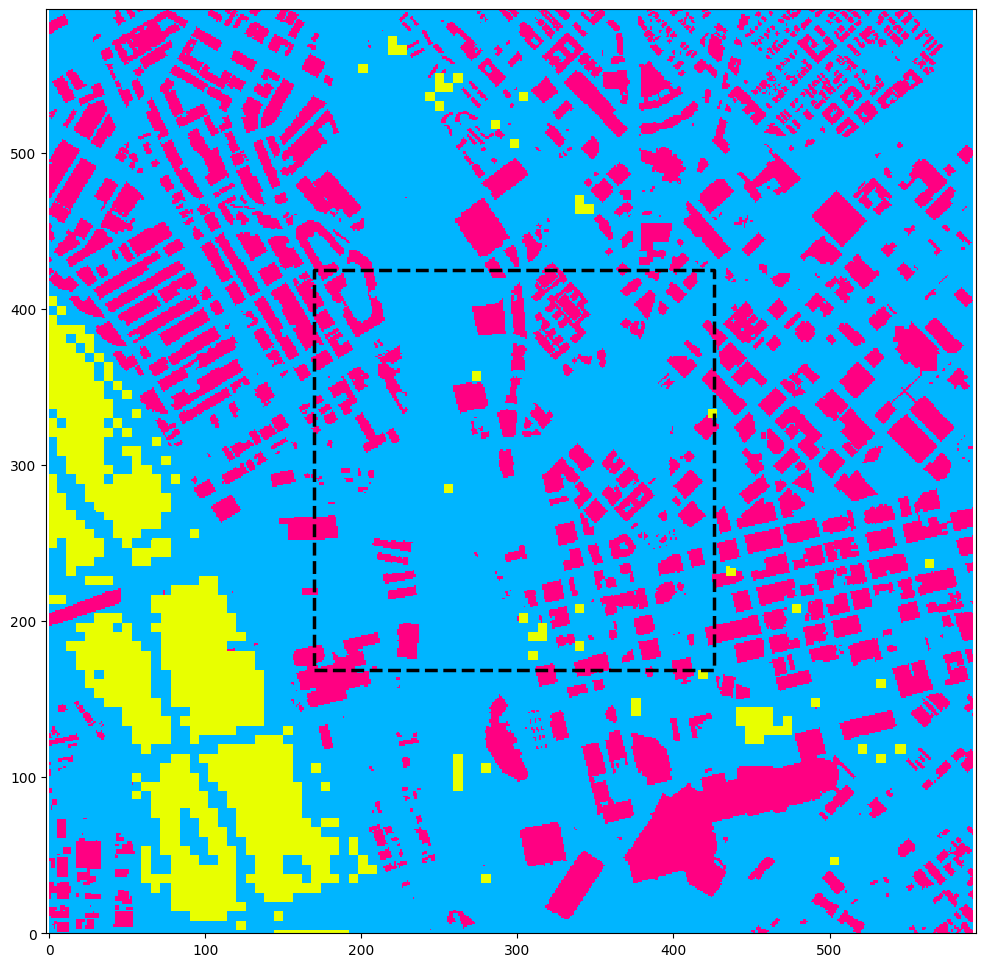

In [35]:
bmask = ds['BuildingMask'].values
bmask[LU==71] = -1

fig = plt.figure(figsize=(12, 12))
plt.pcolormesh(bmask, vmin=-1.5, vmax=1.2, cmap=plt.cm.hsv)

x = [320-150, 576-150, 576-150, 320-150, 320-150]
y = [319-150, 319-150, 575-150, 575-150, 319-150]

plt.plot(x, y, 'k--', lw=2.5)
plt.axis("equal")
plt.xlim([0, 592])
plt.ylim([0, 592])

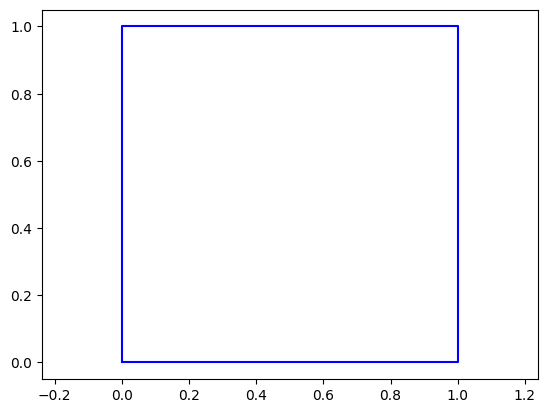

In [28]:
x = [0, 1, 1, 0, 0]
y = [0, 0, 1, 1, 0]

plt.plot(x, y, 'b-')  # 'b-' = blue line
plt.axis("equal")     # keep aspect ratio square
plt.show()

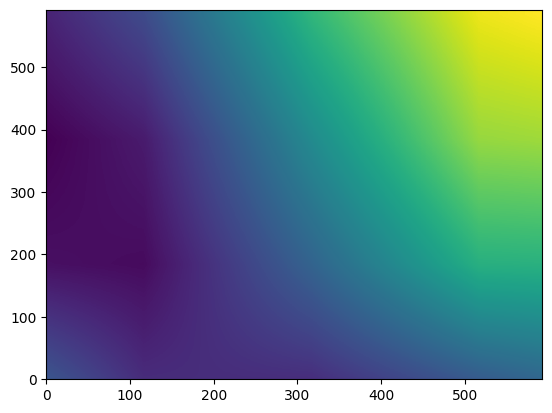

In [14]:
plt.pcolormesh(ds['topoWRF'].values)